<a href="https://colab.research.google.com/github/Hania-Shafiq/mnist-digit-classification/blob/main/deep_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

**LOAD THE DATA SET**

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
# Checking shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
y_train shape: (60000,)
y_test shape: (10000,)


**NORMALIZE THE DATA**

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

**BUILDING DEEP NEURAL NETWORK**

In [5]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**MODEL TRAINING**

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9256 - loss: 0.2537 - val_accuracy: 0.9697 - val_loss: 0.1088
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9672 - loss: 0.1074 - val_accuracy: 0.9750 - val_loss: 0.0862
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9778 - loss: 0.0735 - val_accuracy: 0.9763 - val_loss: 0.0794
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9820 - loss: 0.0557 - val_accuracy: 0.9770 - val_loss: 0.0856
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0442 - val_accuracy: 0.9768 - val_loss: 0.0840
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9881 - loss: 0.0375 - val_accuracy: 0.9785 - val_loss: 0.0815
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9906 - loss: 0.0290 - val_accuracy: 0.9790 - val_loss: 0.0833
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9916 - loss: 0.0255 - 

**EVALUATION**

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9814 - loss: 0.0838
Test accuracy: 0.9814000129699707


**SAMPLE PREDICTION**
Predicting the first 5 test images and visualize them.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


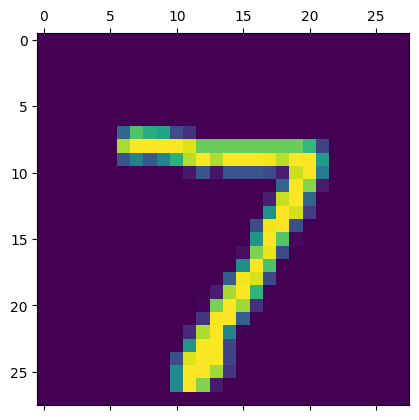

Predicted digit: 7
Actual digit: 7


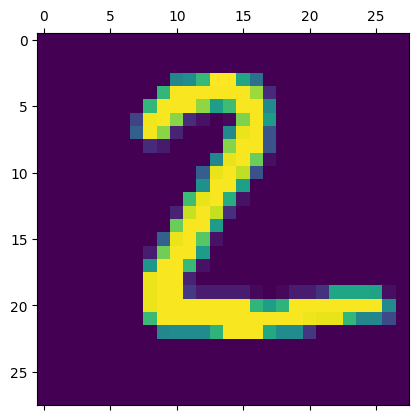

Predicted digit: 2
Actual digit: 2


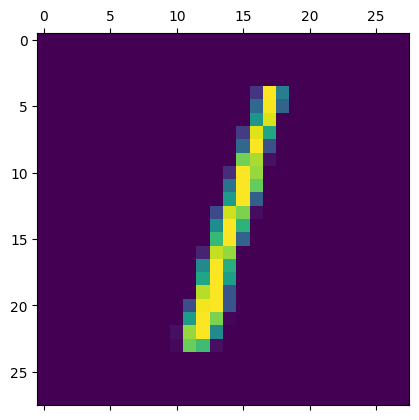

Predicted digit: 1
Actual digit: 1


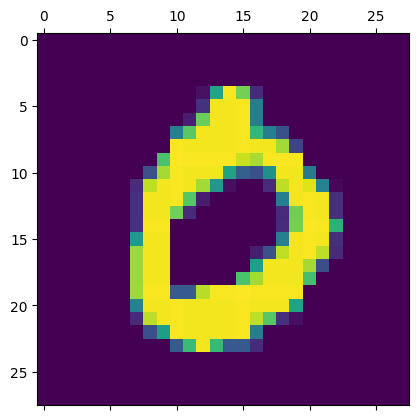

Predicted digit: 0
Actual digit: 0


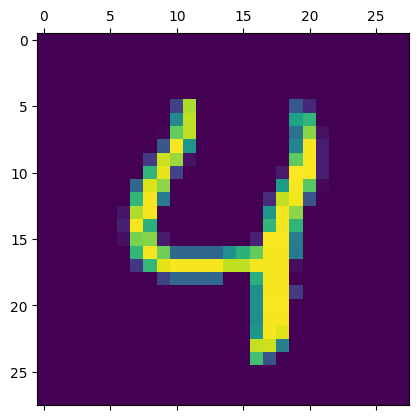

Predicted digit: 4
Actual digit: 4


In [8]:
y_predicted = model.predict(X_test)

for i in range(5):
    plt.matshow(X_test[i])
    plt.show()
    print("Predicted digit:", np.argmax(y_predicted[i]))
    print("Actual digit:", y_test[i])